<a href="https://colab.research.google.com/github/sakaleshhubli/sem7-ML2-/blob/main/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) Template
This notebook demonstrates a structured workflow for loading data, cleaning missing values, calculating summary statistics, and visualizing distributions and correlations.

Implement data loading, cleaning and Exploratory Data Analysis (EDA) on a given dataset using NumPy, Pandas and Matplotlib — handling missing values, summary statistics, distribution and correlation plots.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Loading
First, we load the dataset. (Here we generate a sample dataset for demonstration, but you can replace this with your own file path).

In [ ]:
# Generating a mock dataset with missing values for demonstration purposes
np.random.seed(42)
n_samples = 200

data = {
    'Age': np.random.choice([np.nan, 25, 30, 35, 40, 45, 50, 60], size=n_samples, p=[0.1, 0.15, 0.15, 0.15, 0.15, 0.1, 0.1, 0.1]),
    'Income': np.random.normal(loc=55000, scale=15000, size=n_samples),
    'Score': np.random.randint(1, 100, size=n_samples),
    'Department': np.random.choice(['Sales', 'Engineering', 'HR', 'Marketing', None], size=n_samples, p=[0.3, 0.3, 0.1, 0.2, 0.1])
}

df = pd.DataFrame(data)
# Injecting some more missing values artificially
df.loc[df['Score'] < 15, 'Income'] = np.nan

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (200, 4)


,Age,Income,Score,Department
0,30.0,44799.629176,91,Engineering
1,60.0,58483.805457,74,None
2,45.0,59396.087099,90,Engineering
3,40.0,44284.728730,19,Engineering
4,25.0,82986.617667,39,HR


## 2. Data Cleaning & Handling Missing Values
We identify missing values in the dataset and handle them appropriately using imputation techniques.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

# Impute numerical missing values using the median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())

# Impute categorical missing values with the mode
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values per column:
Age           22
Income        28
Score          0
Department    12
dtype: int64

Missing values after imputation:
Age           0
Income        0
Score         0
Department    0
dtype: int64


## 3. Summary Statistics
Let's get descriptive statistics of our variables.

In [ ]:
print("Numerical summary statistics:")
display(df.describe())

print("\nCategorical summary statistics:")
display(df.describe(include=['O']))

Numerical summary statistics:


,Age,Income,Score
count,200.000000,200.000000,200.000000
mean,38.050000,55729.634111,50.680000
std,10.475984,13436.809090,29.163335
min,25.000000,6380.989899,1.000000
25%,30.000000,45912.436933,26.000000
50%,35.000000,55918.665532,51.000000
75%,45.000000,63984.405032,75.250000
max,60.000000,112790.972360,99.000000



Categorical summary statistics:


,Department
count,200
unique,4
top,Sales
freq,84


## 4. Distribution Plots
Visualizing the distribution of each numerical feature is essential to understand skewness, outliers, and ranges.

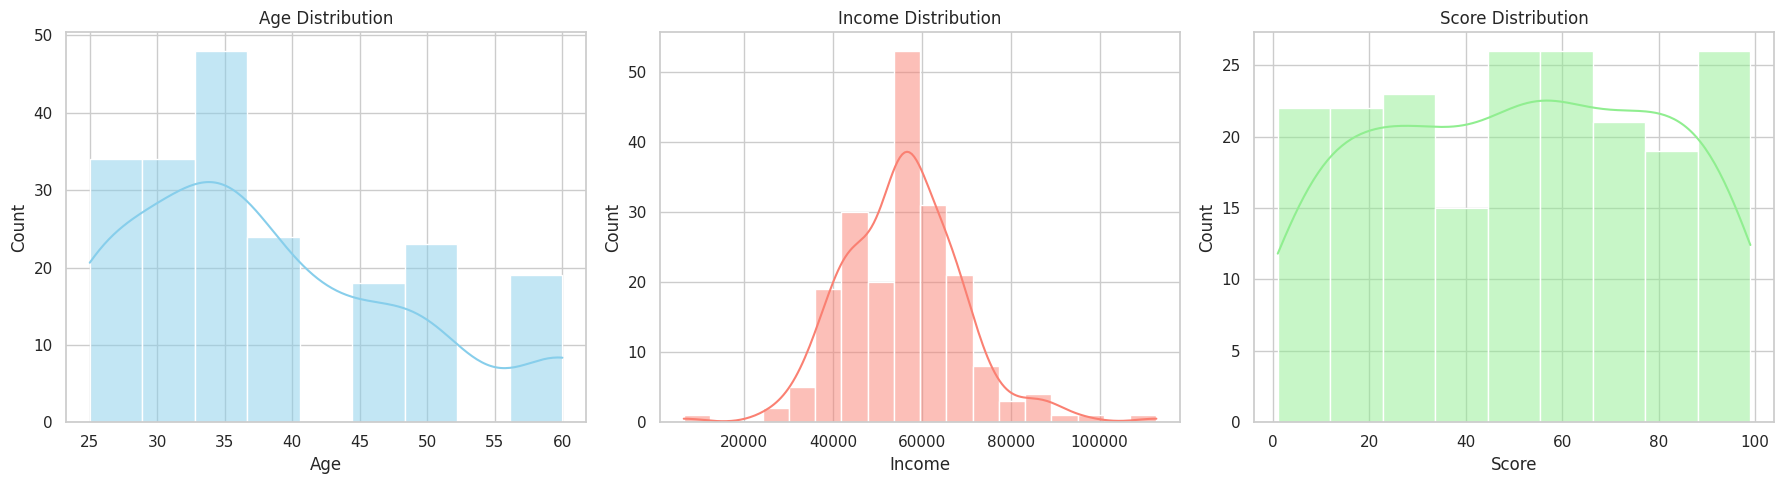

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

# Income Distribution
sns.histplot(df['Income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Income Distribution')

# Score Distribution
sns.histplot(df['Score'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Score Distribution')

plt.tight_layout()
plt.show()

## 5. Correlation Matrix
Let's calculate and plot the pairwise correlations of our numerical features to reveal linear patterns.

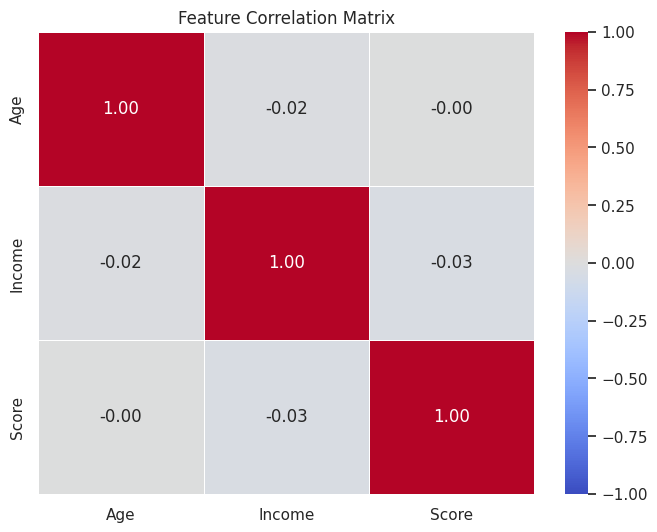

In [ ]:
# Compute correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Display correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()